# **Stage 2 - Pre-Processing**
# **Load ingested data and perform preprocessing.**


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Stage 2: EDA and Preprocessing
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("Libraries loaded.")

# Load ingested data from Stage 1
df = pd.read_csv("/content/drive/MyDrive/Customer Churn Prediction/data/clean/ingested_churn_data.csv")

Libraries loaded.


In [3]:
print(f"Data loaded for cleaning: {df.shape}")
df.head()

Data loaded for cleaning: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Convert TotalCharges to numeric (spaces become NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop missing rows (only ~11 rows)
df.dropna(subset=['TotalCharges'], inplace=True)

# Drop CustomerID as it is not needed for modeling
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

print("Basic cleaning done. Ready for Analysis.")

Basic cleaning done. Ready for Analysis.


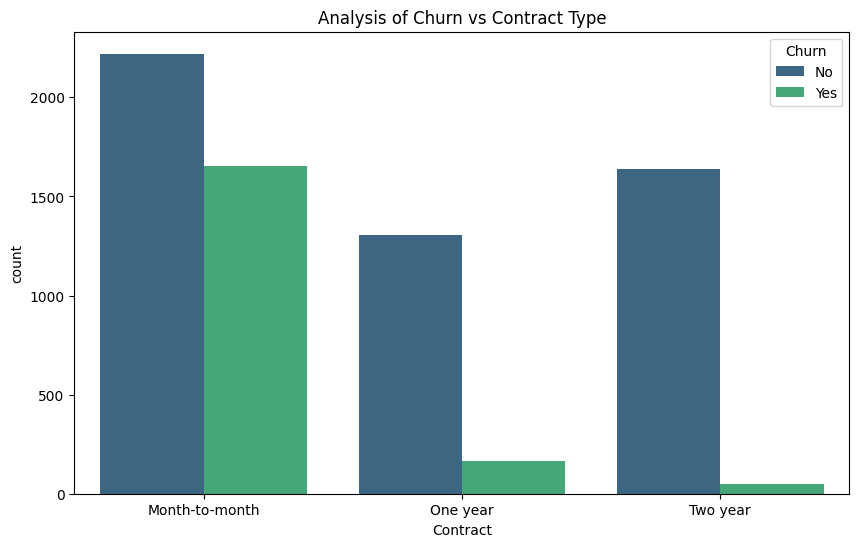

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualization: Churn by Contract Type
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis')
plt.title('Analysis of Churn vs Contract Type')
plt.show()

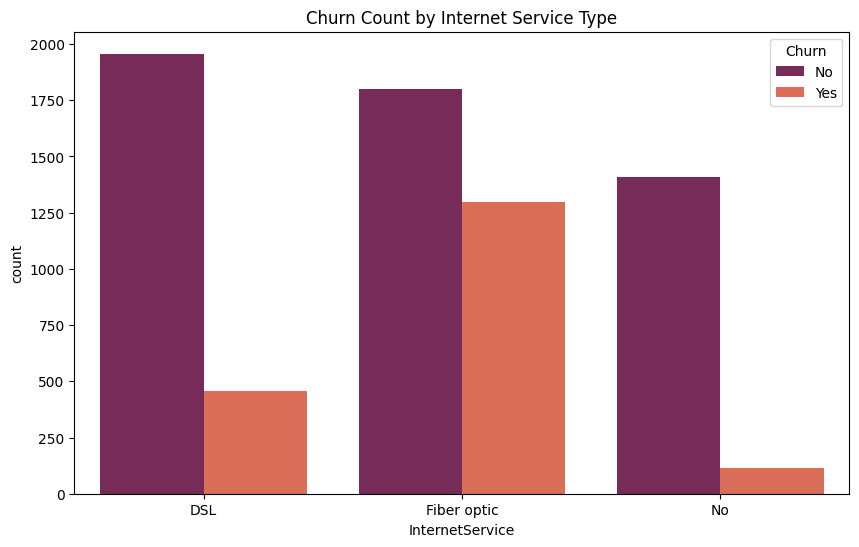

In [6]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='InternetService', hue='Churn', palette='rocket')
plt.title('Churn Count by Internet Service Type')
plt.show()

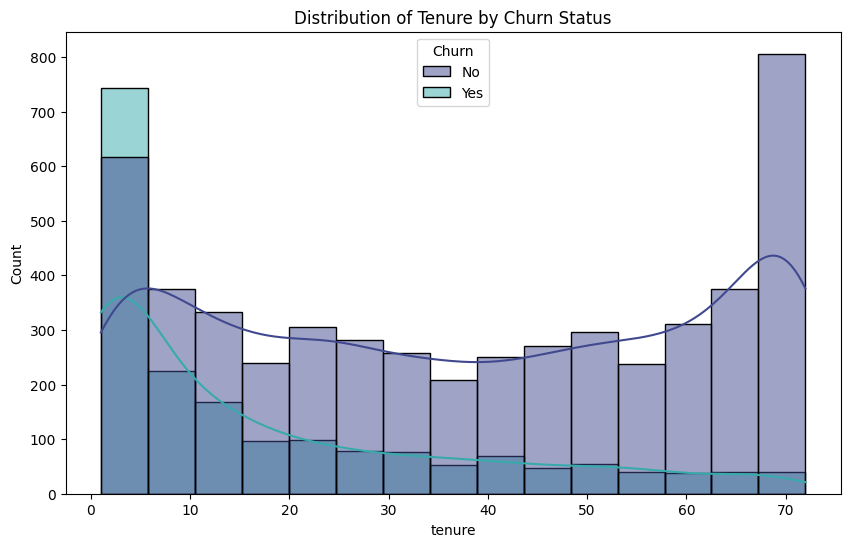

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, palette='mako')
plt.title('Distribution of Tenure by Churn Status')
plt.show()

In [8]:
# 1. Binary Encoding: Converting 'Yes'/'No' to 1/0 for binary columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# 2. Gender Encoding: Mapping Female to 1 and Male to 0
df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})

# 3. One-Hot Encoding: Handling multi-category columns using get_dummies
# drop_first=True is used to avoid the dummy variable trap (redundancy)
categorical_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
                    'OnlineBackup', 'DeviceProtection', 'TechSupport',
                    'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 4. Final Verification: Ensuring all columns are numeric for the BERT/ML model
print("Encoding complete. Data types after preprocessing:")
print(df.dtypes.value_counts())

Encoding complete. Data types after preprocessing:
bool       21
int64       8
float64     2
Name: count, dtype: int64


In [9]:
# Save processed data for Stage 3

df.to_csv("/content/drive/MyDrive/Customer Churn Prediction/data/clean/processed_churn_data.csv", index=False)
print("Stage 2 complete — data saved!")

Stage 2 complete — data saved!
